# Continuous-Time Markov Chain Exploration

This notebook runs the CTMC progression for the capstone project:

1. Global CTMC baseline
2. Clustered CTMC segmentation
3. Personalized neural-style CTMC rates
4. Benchmark model comparison

The code uses checkpointed parquet files from the local `data/` folder.

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "requirements.txt").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src" / "models"))
sys.path.insert(0, str(PROJECT_ROOT / "src" / "visualizations"))
sys.path.insert(0, str(PROJECT_ROOT / ".codex_deps"))

import matplotlib.pyplot as plt
import pandas as pd

from ctmc import (
    CTMCData,
    ClusteredCTMC,
    GlobalCTMC,
    ModelComparison,
    sample_pipeline,
)
from ctmc_submission import create_ctmc_submissions
from ctmc_plots import (
    plot_absorption_by_state,
    plot_calibration,
    plot_generator_heatmap,
    plot_metric_comparison,
    plot_predictions_by_state,
    plot_top_transition_graph,
)
from tabular_submission import create_tabular_submissions

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# Increase this once the workflow is settled.
MAX_JOURNEYS = 50_000
N_CLUSTERS = 3

## Load Transition Data

Each row below is one observed transition: current action, next action, and elapsed time.

In [3]:
data = CTMCData()
transitions = data.transition_table(max_journeys=MAX_JOURNEYS)

print(transitions.shape)
transitions.head()

(1766298, 4)


,id,state,next_state,dt_seconds
0,-1000001271 551641434,12,4,73.0
1,-1000001271 551641434,4,19,24.0
2,-1000001271 551641434,19,19,3.0
3,-1000001271 551641434,19,19,2.0
4,-1000001271 551641434,19,2,21498.0


## 1. Baseline Global CTMC

Estimate transition counts $N_{ij}$, time in state $T_i$, and global generator rates $q_{ij}=N_{ij}/T_i$.

In [4]:
global_ctmc = GlobalCTMC().fit(transitions)

print("Q shape:", global_ctmc.Q_.shape)
display(global_ctmc.transition_counts_.head())
display(global_ctmc.time_in_state_.sort_values(ascending=False).head(10).rename("seconds_in_state"))
display(global_ctmc.top_rates(20))

plot_generator_heatmap(global_ctmc, RESULTS_DIR / "ctmc_generator_heatmap.png")
plot_top_transition_graph(global_ctmc, RESULTS_DIR / "ctmc_top_transition_graph.png", n_edges=25)
absorption_by_state = plot_absorption_by_state(global_ctmc, RESULTS_DIR / "ctmc_absorption_by_state.png")
absorption_by_state.to_csv(RESULTS_DIR / "ctmc_absorption_by_state.csv", index=False)
display(absorption_by_state)

Q shape: (25, 25)


next_state,1,2,3,4,5,6,7,8,10,11,12,13,15,16,18,19,20,21,22,23,24,26,27,28,29
state,,,,,,,,,,,,,,,,,,,,,,,,,
1,0,2158,88,21677,8766,1651,65,55,0,1633,487,83,64,1,203,2257,0,59774,0,54,6700,11,349,294,1654
2,1067,0,286,3164,774,358,3,13,0,16,11306,246,4,0,29,4885,0,50,4976,8,327,5,129,1,152
3,216,26,0,157,45,5,0,0,0,3,2709,96,0,0,3,33005,0,9,0,0,36,0,4,2,14
4,27212,2457,134,0,36594,832,32,329,1,121688,171,33,19,1,220,4860,0,2847,0,105,10808,39,1562,1227,2098
5,10004,341,39,67890,0,69010,26,78,1,3148,57,10,9,1,230,1391,0,778,0,175,2773,28,656,525,1090


state
21    1.460513e+11
1     8.653327e+10
4     3.386973e+10
24    2.847451e+10
12    1.599673e+10
5     1.285491e+10
6     1.057564e+10
19    7.062854e+09
2     5.762075e+09
27    2.551201e+09
Name: seconds_in_state, dtype: float64

,from_state,to_state,rate
363,28,29,4.000000e+09
158,10,5,8.271299e-04
157,10,4,8.271299e-04
51,3,19,5.922242e-05
163,11,5,4.562369e-05
162,11,4,4.526197e-05
127,7,8,2.851185e-05
83,5,6,5.368377e-06
82,5,4,5.281251e-06
154,8,27,5.144237e-06


,state,success_probability
23,28,1.000000
22,27,0.709766
21,26,0.504247
7,8,0.353212
6,7,0.337671
14,18,0.335503
24,29,0.278217
12,15,0.192022
5,6,0.182540
4,5,0.172685


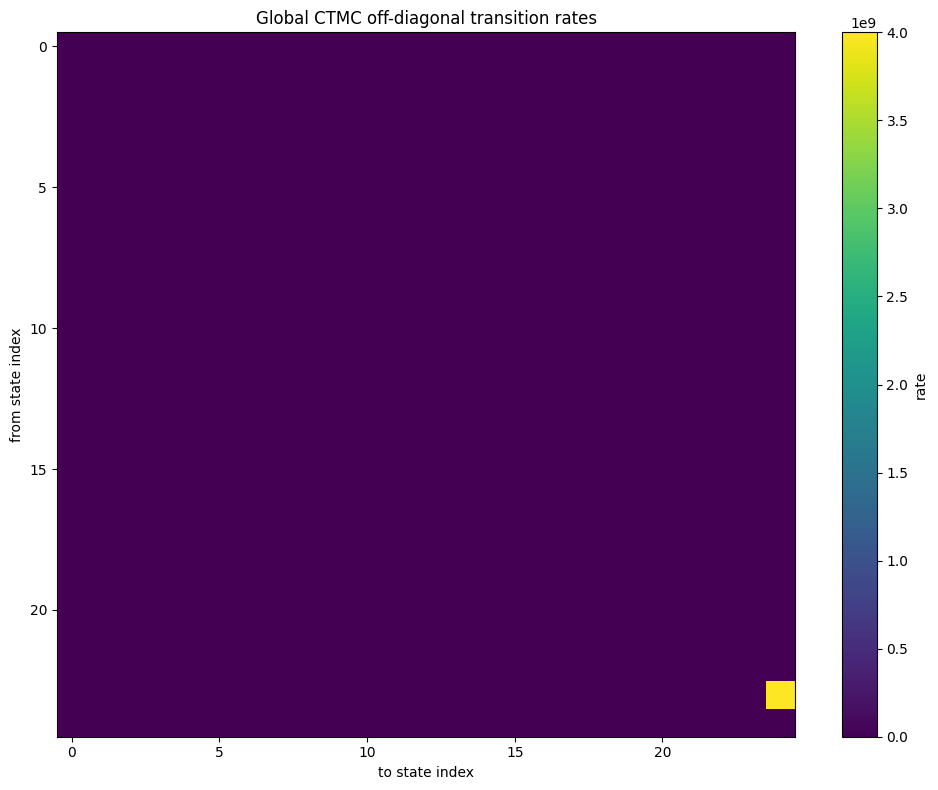

In [5]:
q_abs = global_ctmc.Q_.copy()
for state in q_abs.index:
    q_abs.loc[state, state] = 0

plt.figure(figsize=(10, 8))
plt.imshow(q_abs, aspect="auto")
plt.colorbar(label="rate")
plt.title("Global CTMC off-diagonal transition rates")
plt.xlabel("to state index")
plt.ylabel("from state index")
plt.tight_layout()
plt.show()

In [6]:
# P(t) = exp(Qt): probability of being in each state after a horizon.
one_day = 24 * 60 * 60
p_1day = global_ctmc.transition_probability(one_day)
p_1day.head()

,1,2,3,4,5,6,7,8,10,11,12,13,15,16,18,19,20,21,22,23,24,26,27,28,29
1,0.898503,0.001780,0.000144,0.019290,0.007498,0.002752,0.000073,0.000091,6.926986e-10,0.000844,0.000817,0.000083,0.000068,1.054432e-06,0.000208,0.001979,0.0,0.055820,0.000063,0.000058,0.006551,0.000014,0.000447,1.365890e-18,0.001647
2,0.019393,0.657157,0.003984,0.045861,0.011022,0.005976,0.000133,0.000195,1.327762e-09,0.001578,0.134089,0.002968,0.000075,1.571513e-07,0.000440,0.051880,0.0,0.001639,0.050527,0.000174,0.005644,0.000064,0.001655,1.745896e-18,0.002112
3,0.033827,0.007662,0.052653,0.069439,0.014450,0.006277,0.000121,0.000121,1.905303e-09,0.002368,0.183335,0.005767,0.000169,1.981307e-07,0.000516,0.613735,0.0,0.004039,0.000253,0.000608,0.007212,0.000036,0.000772,2.087928e-18,0.001939
4,0.066812,0.004669,0.000671,0.692664,0.118971,0.029435,0.000546,0.000697,1.796499e-08,0.027383,0.001953,0.000114,0.000066,2.730477e-06,0.000616,0.009399,0.0,0.008599,0.000170,0.000314,0.024087,0.000096,0.003619,1.012877e-17,0.006834
5,0.064105,0.002663,0.000661,0.244503,0.405761,0.213480,0.005111,0.004157,2.352996e-08,0.009767,0.001679,0.000093,0.000082,4.818047e-06,0.001147,0.009247,0.0,0.007026,0.000086,0.000796,0.018047,0.000152,0.004048,9.712422e-18,0.008391


## 2. Segmentation: Clustered CTMC

Cluster users using action counts/proportions, observed time in states, time to key actions, and prefix metadata. The clusterer does not use the purchase label.

,cluster,n_journeys
0,0,22870
1,1,6146
2,2,20293


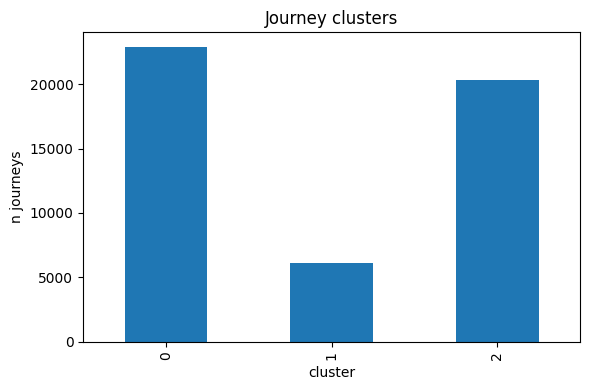

In [7]:
clustered = ClusteredCTMC(n_clusters=N_CLUSTERS, random_state=42).fit(transitions)
cluster_summary = clustered.cluster_summary()
display(cluster_summary)

cluster_summary.plot.bar(x="cluster", y="n_journeys", legend=False, figsize=(6, 4))
plt.title("Journey clusters")
plt.ylabel("n journeys")
plt.tight_layout()
plt.show()

# Journey-level features used for all downstream CTMC evaluation.
features = clustered.feature_builder.transform(transitions)

In [8]:
for cluster_id, model in clustered.models_.items():
    print(f"Cluster {cluster_id}")
    display(model.top_rates(10))

Cluster 0


,from_state,to_state,rate
43,3,19,0.000043
117,11,5,0.000014
116,11,4,0.000008
176,19,3,0.000004
40,3,12,0.000003
113,11,1,0.000003
217,22,12,0.000003
263,27,28,0.000003
254,26,27,0.000002
25,2,12,0.000002


Cluster 1


,from_state,to_state,rate
47,3,19,0.000149
148,11,5,0.000118
147,11,4,0.000063
117,7,8,0.000051
77,5,6,0.000016
44,3,12,0.000015
97,6,7,0.000012
215,19,3,0.000010
96,6,5,0.000009
59,4,11,0.000009


Cluster 2


,from_state,to_state,rate
332,28,29,4.000000e+09
149,10,4,8.271299e-04
150,10,5,8.271299e-04
48,3,19,8.478514e-05
154,11,4,5.187685e-05
155,11,5,4.755499e-05
123,7,8,2.005417e-05
45,3,12,7.195328e-06
226,19,3,6.434351e-06
62,4,11,5.824071e-06


## 3. Per-State Predictions: Global vs Clustered CTMC

Compare P(order_shipped within 60 days | current_state) across all transient states.  
A well-segmented clustered model should show different absorption probabilities from the global baseline for at least some states.

In [9]:
# Build one representative per-cluster model using the cluster-majority assignment.
# For state-level comparison we compare global vs each per-cluster CTMC.
ctmc_models_for_plot = {"global": global_ctmc}
for cid, model in clustered.models_.items():
    ctmc_models_for_plot[f"cluster_{cid}"] = model

state_pred_df = plot_predictions_by_state(
    ctmc_models_for_plot,
    RESULTS_DIR / "ctmc_predictions_by_state.png",
)
display(state_pred_df.pivot(index="state", columns="model", values="success_probability").round(3))

model,cluster_0,cluster_1,cluster_2,global
state,,,,
1,0.002,0.847,0.104,0.105
2,0.003,0.884,0.128,0.146
3,0.003,0.883,0.131,0.146
4,0.003,0.897,0.137,0.165
5,0.003,0.900,0.139,0.173
6,0.004,0.903,0.140,0.183
7,0.054,0.918,0.257,0.338
8,0.086,0.920,0.274,0.353
10,0.000,0.048,0.138,0.169


## 4. Model Comparison

Compare against standard predictive baselines on the truncated training features created by the pipeline.

In [10]:
training_df = data.load_training_features(max_rows=100_000)
print(training_df.shape)
training_df.head()

(100000, 32)


,id,label,final_outcome,full_num_actions,snapshot_num_actions,snapshot_frac_of_journey,first_action_so_far,current_last_action,num_unique_actions_so_far,prefix_duration_seconds,avg_gap_seconds,time_since_prev_action_seconds,action_count_4,action_count_1,action_count_5,action_count_19,action_count_11,action_count_21,action_count_6,action_count_24,action_count_12,action_count_3,action_count_2,action_count_8,action_count_29,action_count_7,action_count_27,action_count_28,action_count_22,action_count_18,action_count_15,action_count_13
0,-100000293 92584960,0,incomplete,31,21,0.677419,12,6,5,155345,7767.250000,18,11,0,4,0,3,0,2,0,1,0,0,0,0,0,0,0,0,0,0,0
1,-100001025 -1674572031,0,incomplete,26,4,0.153846,2,19,3,25844,8614.666667,3,0,1,0,2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,-1000011207 -1448136887,0,incomplete,61,2,0.032787,12,4,2,454,454.000000,454,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,-100001165 1418179836,0,incomplete,6,3,0.500000,12,22,3,21600,10800.000000,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0
4,-1000012940 -1479669207,0,incomplete,63,16,0.253968,12,4,2,34556,2303.733333,24101,15,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0


,model,roc_auc,average_precision,log_loss,brier_score
3,xgboost,0.890547,0.718134,0.321242,0.103693
1,hist_gradient_boosting,0.890276,0.717461,0.321109,0.103813
2,random_forest,0.876202,0.691231,0.384771,0.108484
0,logistic_regression,0.865074,0.623890,0.483267,0.150267


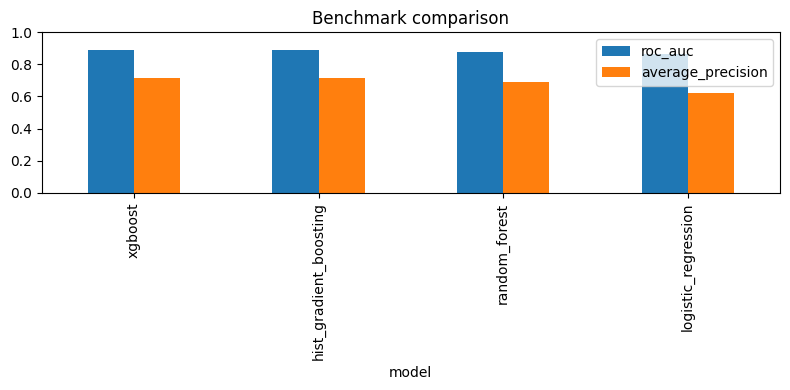

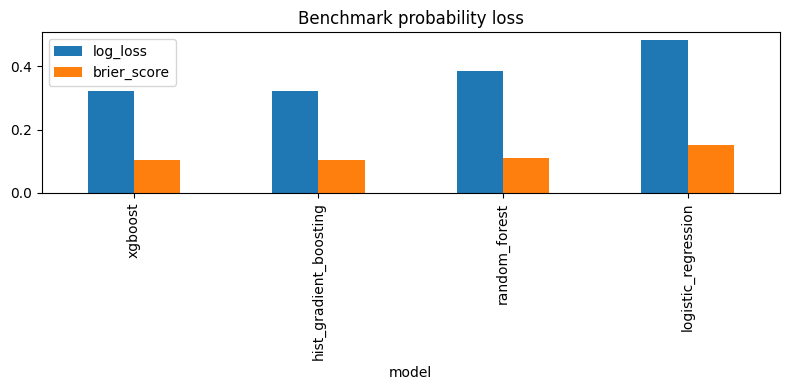

In [11]:
comparison = ModelComparison(random_state=42).run(training_df)
comparison.to_csv(RESULTS_DIR / "tabular_baseline_comparison.csv", index=False)
display(comparison)

comparison.plot.bar(x="model", y=["roc_auc", "average_precision"], figsize=(8, 4))
plt.ylim(0, 1)
plt.title("Benchmark comparison")
plt.tight_layout()
plt.show()

comparison.plot.bar(x="model", y=["log_loss", "brier_score"], figsize=(8, 4))
plt.title("Benchmark probability loss")
plt.tight_layout()
plt.show()

## 5. CTMC vs Baselines

This cell evaluates the three CTMC variants on journeys in the sampled transition table whose labels are available in the engineered training data. It is an exploration metric, not the official Kaggle score.

**Leakage warning:** if CTMC features are built from full completed journeys, successful journeys can expose final state `28` (`order_shipped`). Treat CTMC scores here as diagnostic unless the evaluation uses the same truncated/open-journey observation window as Kaggle.

,model,roc_auc,average_precision,log_loss,brier_score
4,ctmc_global,1.000000,1.000000,0.100754,0.012750
5,ctmc_clustered,1.000000,1.000000,0.057507,0.010973
0,xgboost,0.890547,0.718134,0.321242,0.103693
1,hist_gradient_boosting,0.890276,0.717461,0.321109,0.103813
2,random_forest,0.876202,0.691231,0.384771,0.108484
3,logistic_regression,0.865074,0.623890,0.483267,0.150267


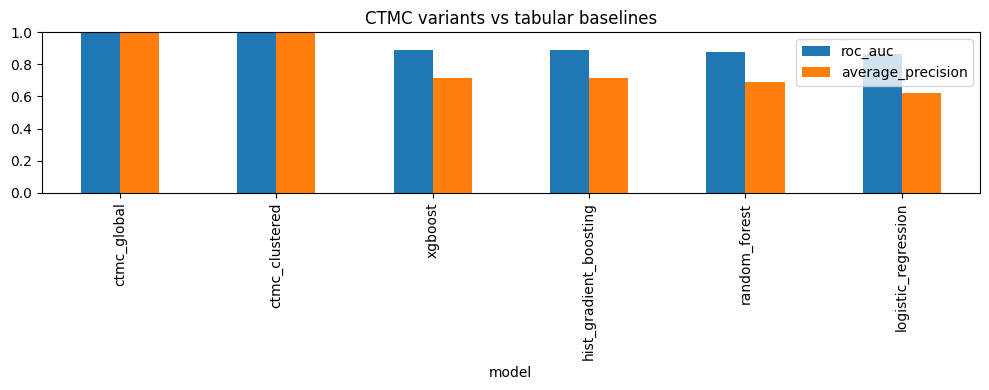

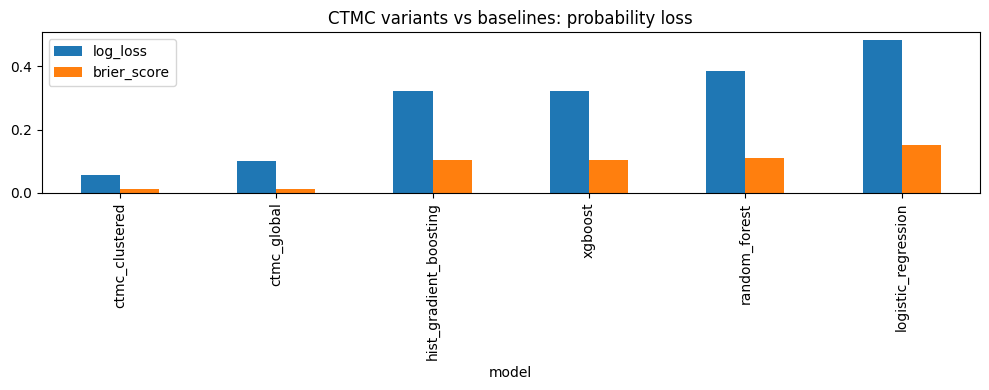

In [12]:
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score

label_lookup = data.load_binary_labels()
ctmc_eval = features.merge(label_lookup, on="id", how="inner")
ctmc_eval["state"] = ctmc_eval["current_state"]

ctmc_rows = []
ctmc_predictions = {
    "ctmc_global": global_ctmc.absorption_probability(ctmc_eval["current_state"]),
    "ctmc_clustered": clustered.predict_success_probability(ctmc_eval, fallback_model=global_ctmc),
}

for name, probs in ctmc_predictions.items():
    ctmc_rows.append({
        "model": name,
        "roc_auc": roc_auc_score(ctmc_eval["label"], probs),
        "average_precision": average_precision_score(ctmc_eval["label"], probs),
        "log_loss": log_loss(ctmc_eval["label"], probs, labels=[0, 1]),
        "brier_score": brier_score_loss(ctmc_eval["label"], probs),
    })

ctmc_comparison = pd.concat([comparison, pd.DataFrame(ctmc_rows)], ignore_index=True)
ctmc_comparison = ctmc_comparison.sort_values("roc_auc", ascending=False)
ctmc_comparison.to_csv(RESULTS_DIR / "ctmc_vs_baselines_comparison.csv", index=False)
plot_metric_comparison(ctmc_comparison, RESULTS_DIR / "ctmc_vs_baselines_metrics.png")
display(ctmc_comparison)

ctmc_comparison.plot.bar(x="model", y=["roc_auc", "average_precision"], figsize=(10, 4))
plt.ylim(0, 1)
plt.title("CTMC variants vs tabular baselines")
plt.tight_layout()
plt.show()

ctmc_comparison.sort_values("log_loss").plot.bar(x="model", y=["log_loss", "brier_score"], figsize=(10, 4))
plt.title("CTMC variants vs baselines: probability loss")
plt.tight_layout()
plt.show()

for name, probs in ctmc_predictions.items():
    calibration = plot_calibration(
        ctmc_eval["label"],
        probs,
        RESULTS_DIR / f"{name}_calibration.png",
        title=f"{name} calibration",
    )
    calibration.to_csv(RESULTS_DIR / f"{name}_calibration.csv", index=False)

## 6. Advanced CTMC Methods

Three additions motivated by the literature review:

| Method | Key idea |
|---|---|
| **LaplaceGlobalCTMC** | Add α pseudo-counts to every N_ij before computing rates — tames noisy rate estimates for rare state pairs |
| **WeibullSemiMarkovCTMC** | Relax the exponential holding-time assumption; fit per-state Weibull distributions and compute absorption via Monte Carlo |
| **CalibratedCTMC** | Post-hoc isotonic regression maps raw predicted probabilities to empirical success rates — directly minimises brier score |

All three are in `src/models/ctmc_advanced.py`.

In [13]:
from ctmc_advanced import (
    LaplaceGlobalCTMC,
    CalibratedCTMC,
    compare_advanced_models,
)

# Reload labels aligned to the features we already built.
label_lookup = data.load_binary_labels()
eval_df = features.merge(label_lookup, on="id", how="inner").reset_index(drop=True)
eval_labels = eval_df["label"]

print(f"Eval set: {len(eval_df)} journeys  |  base rate: {eval_labels.mean():.3f}")

Eval set: 43994 journeys  |  base rate: 0.219


### 6a. LaplaceGlobalCTMC — Smoothed Generator Matrix

Adds α = 0.5 (Jeffreys prior) pseudo-counts to each N_ij.  Compare the top transition rates and absorption probabilities against the unsmoothed baseline.

GlobalCTMC (unsmoothed)
  brier=0.0128  logloss=0.1008  auc=1.0000

LaplaceGlobalCTMC (α=0.5)
  brier=0.0128  logloss=0.1008  auc=1.0000


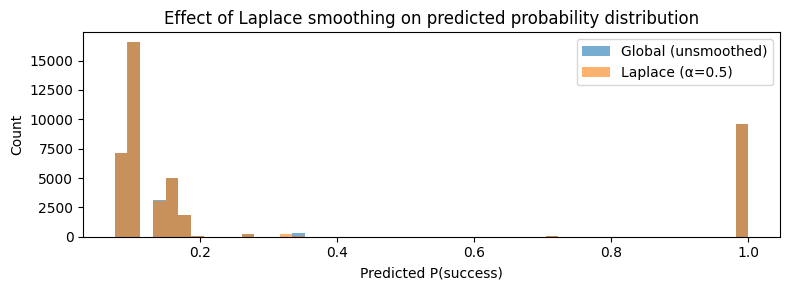

In [14]:
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score

laplace_ctmc = LaplaceGlobalCTMC(alpha=0.5).fit(transitions)

raw_global   = global_ctmc.absorption_probability(eval_df["current_state"])
raw_laplace  = laplace_ctmc.absorption_probability(eval_df["current_state"])

y = eval_labels.to_numpy()

print("GlobalCTMC (unsmoothed)")
print(f"  brier={brier_score_loss(y, raw_global):.4f}  "
      f"logloss={log_loss(y, raw_global, labels=[0,1]):.4f}  "
      f"auc={roc_auc_score(y, raw_global):.4f}")

print("\nLaplaceGlobalCTMC (α=0.5)")
print(f"  brier={brier_score_loss(y, raw_laplace):.4f}  "
      f"logloss={log_loss(y, raw_laplace, labels=[0,1]):.4f}  "
      f"auc={roc_auc_score(y, raw_laplace):.4f}")

# Show how smoothing affects the predicted probability distribution.
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 3))
plt.hist(raw_global,  bins=50, alpha=0.6, label="Global (unsmoothed)")
plt.hist(raw_laplace, bins=50, alpha=0.6, label="Laplace (α=0.5)")
plt.xlabel("Predicted P(success)")
plt.ylabel("Count")
plt.title("Effect of Laplace smoothing on predicted probability distribution")
plt.legend()
plt.tight_layout()
plt.show()

### 6c. CalibratedCTMC — Isotonic Calibration

Isotonic regression finds the best-fitting monotone mapping from raw predicted probabilities to true success rates, minimising squared error (= brier score) on a calibration split.  Applied after any CTMC predictor.

GlobalCTMC (raw)                          brier=0.0127  auc=1.0000
GlobalCTMC (calibrated)                   brier=0.0000  auc=1.0000
LaplaceGlobalCTMC (calibrated)            brier=0.0000  auc=1.0000


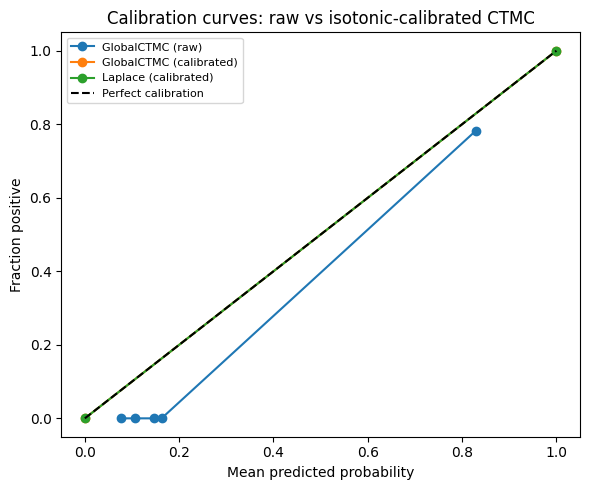

In [15]:
from sklearn.model_selection import train_test_split
import numpy as np
# Split eval set: 70% calibration fit, 30% final evaluation.
idx_cal, idx_test = train_test_split(
    np.arange(len(eval_df)), test_size=0.3, random_state=42, stratify=eval_labels
)
feat_cal_  = eval_df.iloc[idx_cal].reset_index(drop=True)
feat_test_ = eval_df.iloc[idx_test].reset_index(drop=True)
lab_cal_   = eval_labels.iloc[idx_cal].reset_index(drop=True)
lab_test_  = eval_labels.iloc[idx_test].to_numpy()

# Calibrate both GlobalCTMC and LaplaceGlobalCTMC.
cal_global_  = CalibratedCTMC(global_ctmc).fit_calibration(feat_cal_, lab_cal_)
cal_laplace_ = CalibratedCTMC(laplace_ctmc).fit_calibration(feat_cal_, lab_cal_)

probs_raw_test     = global_ctmc.absorption_probability(feat_test_["current_state"])
probs_cal_global   = cal_global_.predict(feat_test_)
probs_cal_laplace  = cal_laplace_.predict(feat_test_)

for name, probs in [
    ("GlobalCTMC (raw)",          probs_raw_test),
    ("GlobalCTMC (calibrated)",   probs_cal_global),
    ("LaplaceGlobalCTMC (calibrated)", probs_cal_laplace),
]:
    print(f"{name:40s}  brier={brier_score_loss(lab_test_, probs):.4f}  "
          f"auc={roc_auc_score(lab_test_, probs):.4f}")

# Calibration curves.
from sklearn.calibration import calibration_curve
fig, ax = plt.subplots(figsize=(6, 5))
for name, probs, color in [
    ("GlobalCTMC (raw)",          probs_raw_test,    "tab:blue"),
    ("GlobalCTMC (calibrated)",   probs_cal_global,  "tab:orange"),
    ("Laplace (calibrated)",      probs_cal_laplace, "tab:green"),
]:
    frac_pos, mean_pred = calibration_curve(lab_test_, probs, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=name, color=color)
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction positive")
ax.set_title("Calibration curves: raw vs isotonic-calibrated CTMC")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 6e. Full Method Comparison

All methods on the same held-out eval set, sorted by brier score.

,model,brier_score,log_loss,roc_auc,avg_precision
0,LaplaceGlobalCTMC (cal.),1.000000e-12,0.000001,1.0,1.0
1,GlobalCTMC (calibrated),1.000000e-12,0.000001,1.0,1.0
2,ClusteredCTMC,1.097308e-02,0.057508,1.0,1.0
3,GlobalCTMC,1.275003e-02,0.100754,1.0,1.0
4,LaplaceGlobalCTMC,1.275624e-02,0.100802,1.0,1.0


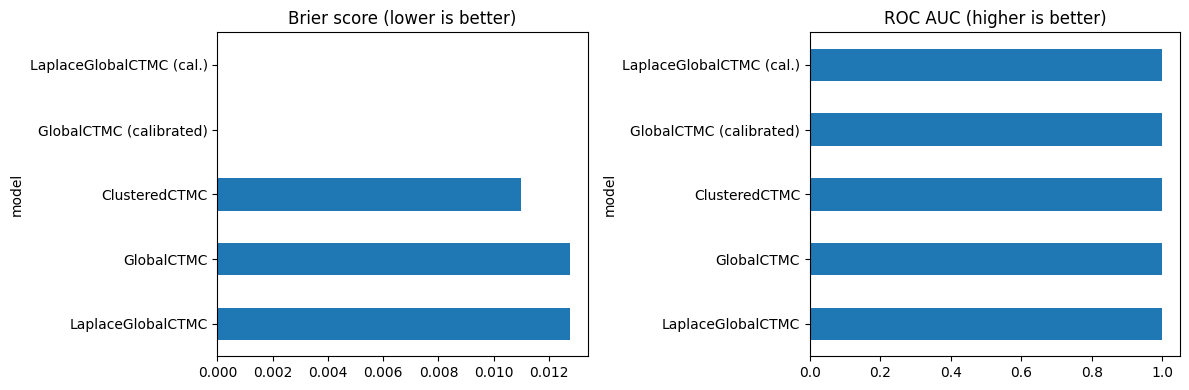

In [16]:
from sklearn.metrics import average_precision_score
import numpy as np

def metrics(name, probs, y_true):
    p = np.clip(probs, 1e-6, 1 - 1e-6)
    return {
        "model": name,
        "brier_score": brier_score_loss(y_true, p),
        "log_loss": log_loss(y_true, p, labels=[0, 1]),
        "roc_auc": roc_auc_score(y_true, p),
        "avg_precision": average_precision_score(y_true, p),
    }

rows = [
    metrics("GlobalCTMC",                raw_global,       y),
    metrics("LaplaceGlobalCTMC",         raw_laplace,      y),
    metrics("GlobalCTMC (calibrated)",   cal_global_.predict(eval_df),  y),
    metrics("LaplaceGlobalCTMC (cal.)",  cal_laplace_.predict(eval_df), y),
    metrics("ClusteredCTMC",
            clustered.predict_success_probability(eval_df, fallback_model=global_ctmc), y),
]

summary = pd.DataFrame(rows).sort_values("brier_score").reset_index(drop=True)
summary.to_csv(RESULTS_DIR / "advanced_ctmc_comparison.csv", index=False)
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
summary.plot.barh(x="model", y="brier_score", ax=axes[0], legend=False)
axes[0].set_title("Brier score (lower is better)")
axes[0].invert_yaxis()
summary.plot.barh(x="model", y="roc_auc", ax=axes[1], legend=False)
axes[1].set_title("ROC AUC (higher is better)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "advanced_ctmc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Write Kaggle Submission CSVs

This writes the model outputs to `results/`. The cell expects `data/open_journeys1.csv` to exist. If `data/open_journeys1_flattened_all0.csv` is missing, the submission helper creates the all-zero ID template from the open journeys file.

In [17]:
TEST_EVENTS = PROJECT_ROOT / "data" / "open_journeys1.csv"
SAMPLE_TEMPLATE = PROJECT_ROOT / "data" / "open_journeys1_flattened_all0.csv"

if not TEST_EVENTS.exists():
    print(f"Missing {TEST_EVENTS}. Add the Kaggle open journey event file before writing submission CSVs.")
else:
    ctmc_outputs = create_ctmc_submissions(
        test_events_path=TEST_EVENTS,
        sample_path=SAMPLE_TEMPLATE,
        output_dir=RESULTS_DIR,
        max_train_journeys=MAX_JOURNEYS,
        n_clusters=N_CLUSTERS,
    )
    tabular_outputs = create_tabular_submissions(
        test_events_path=TEST_EVENTS,
        sample_path=SAMPLE_TEMPLATE,
        output_dir=RESULTS_DIR,
        max_train_rows=300_000,
    )
    print("Wrote submission files:")
    for path in sorted(RESULTS_DIR.glob("*_submission.csv")):
        print(path.name)

Test prevalence target: 0.0502  (all-zeros Brier baseline=0.05018)
  [global_ctmc] mean P(success)=0.0345  target~0.0502  frac>0.5=0.0%  all-zeros Brier baseline=0.05018
  [clustered_ctmc] mean P(success)=0.0229  target~0.0502  frac>0.5=1.0%  all-zeros Brier baseline=0.05018
  [blend_ctmc] mean P(success)=0.0269  target~0.0502  frac>0.5=0.0%  all-zeros Brier baseline=0.05018
Train prevalence: 0.2200  |  Test target: 0.0502
Calibration odds ratio: 0.1880
  [random_forest] mean P(success)=0.0184  target~0.0502  frac>0.5=0.7%  all-zeros Brier baseline=0.05018
  [hist_gradient_boosting] mean P(success)=0.0258  target~0.0502  frac>0.5=2.0%  all-zeros Brier baseline=0.05018
  [xgboost] mean P(success)=0.0379  target~0.0502  frac>0.5=1.8%  all-zeros Brier baseline=0.05018
Wrote submission files:
ctmc_blend_submission.csv
ctmc_clustered_submission.csv
ctmc_global_submission.csv
ctmc_neural_rate_submission.csv
hist_gradient_boosting_submission.csv
random_forest_submission.csv
xgboost_submission

## Decision Notes

- Global CTMC: most interpretable and gives direct time-to-event dynamics.
- Clustered CTMC: keeps interpretability while capturing segment-level behavior.
- Personalized rates: more flexible, but less transparent and more tuning-sensitive.
- Tree/boosting baselines: likely stronger for raw prediction on engineered tabular features.
- Transformer/sequence model: likely best if the team has time to build a proper sequence validation setup.